In [1]:
import os, io, random, collections, warnings
from pathlib import Path
import numpy as np
import cv2
from PIL import Image, ImageChops
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, balanced_accuracy_score,
                              ConfusionMatrixDisplay, confusion_matrix)

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

ROOT   = Path(r"C:\Users\Windows\Documents\CASIA2")
AU_DIR = ROOT / "Au"
TP_DIR = ROOT / "Tp"

def get_tp_label(p: Path) -> int:
    parts = p.stem.split('_')
    return 1 if (len(parts) >= 3 and parts[-3] == parts[-2]) else 2

EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
au_paths = sorted([p for p in AU_DIR.iterdir() if p.suffix.lower() in EXTS])
tp_paths = sorted([p for p in TP_DIR.iterdir() if p.suffix.lower() in EXTS])
cm_paths = [p for p in tp_paths if get_tp_label(p) == 1]
sp_paths = [p for p in tp_paths if get_tp_label(p) == 2]

NAMES  = {0: "Authentic", 1: "Copy-Move", 2: "Splicing"}
COLORS = {0: "steelblue", 1: "tomato",    2: "seagreen"}

print(f"Authentic : {len(au_paths)}")
print(f"Copy-Move : {len(cm_paths)}")
print(f"Splicing  : {len(sp_paths)}")

Authentic : 7491
Copy-Move : 3299
Splicing  : 1824


In [2]:
def akaze_copymove_score(path, min_dist_px=25, ratio_thresh=0.80):
    """
    Detect copy-move by matching AKAZE descriptors within a single image.

    Key improvements over the baseline notebook:
    - RANSAC homography check filters out matches from natural repeating textures
      (bricks, fabric, foliage) which were the main source of false positives.
    - Inlier density normalises for image resolution.
    - Score uses a sigmoid-like curve saturating at ~30 RANSAC inliers.

    Returns: (score [0,1], n_inliers, matched_pairs_list)
    """
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0, 0, []

    h, w = img.shape
    scale = 512 / max(h, w)
    img_s = cv2.resize(img, (int(w * scale), int(h * scale)))

    akaze = cv2.AKAZE_create(threshold=0.0005)
    kps, descs = akaze.detectAndCompute(img_s, None)

    if descs is None or len(kps) < 10:
        return 0.0, 0, []

    # k=3: triplet[0] is the self-match (distance=0), so we skip it
    bf  = cv2.BFMatcher(cv2.NORM_HAMMING)
    raw = bf.knnMatch(descs, descs, k=3)

    candidates = []
    for trip in raw:
        if len(trip) < 3:
            continue
        m, n = trip[1], trip[2]
        if m.distance < ratio_thresh * n.distance:
            pt1 = np.array(kps[m.queryIdx].pt)
            pt2 = np.array(kps[m.trainIdx].pt)
            if np.linalg.norm(pt1 - pt2) > min_dist_px:
                candidates.append((kps[m.queryIdx], kps[m.trainIdx], m.distance))

    # RANSAC geometric consistency: a real copy-move forms a consistent
    # homography; random texture repeats do not
    n_inliers = 0
    if len(candidates) >= 8:
        src_pts = np.float32([c[0].pt for c in candidates]).reshape(-1, 1, 2)
        dst_pts = np.float32([c[1].pt for c in candidates]).reshape(-1, 1, 2)
        _, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        if mask is not None:
            n_inliers = int(mask.sum())
            candidates = [c for c, m in zip(candidates, mask.ravel()) if m]
    else:
        n_inliers = len(candidates)

    score = float(1.0 - np.exp(-n_inliers / 15.0))
    return score, n_inliers, candidates


def visualize_copymove(path, candidates):
    """Draw RANSAC-verified copy-move match lines on the image."""
    img_bgr = cv2.imread(str(path))
    h, w = img_bgr.shape[:2]
    scale = 512 / max(h, w)
    canvas = cv2.cvtColor(
        cv2.resize(img_bgr, (int(w * scale), int(h * scale))), cv2.COLOR_BGR2RGB
    )
    for kp1, kp2, _ in (candidates or [])[:60]:
        p1 = tuple(map(int, kp1.pt))
        p2 = tuple(map(int, kp2.pt))
        cv2.line(canvas, p1, p2, (255, 80, 80), 1)
        cv2.circle(canvas, p1, 3, (255, 200, 0), -1)
        cv2.circle(canvas, p2, 3, (0, 200, 255), -1)
    return canvas

In [3]:
def ela_splicing_score(path, quality=92, block_size=64):
    """
    Detect splicing via spatial inconsistency in ELA residuals.

    Core insight: a spliced region was JPEG-compressed under a different
    history than the host image. Recompressing at a fixed quality reveals
    this mismatch as abnormally high ELA in the pasted region, making
    *block-level variance* — not global ELA mean — the discriminative feature.

    Three sub-scores:
      block_std  : std of per-block ELA means (compression history mismatch)
      lvar_max   : peak of local variance map (spatial patchiness)
      ela_std    : global ELA std (secondary signal)

    Returns: (score [0,1], feature_dict)
    """
    try:
        img_pil = Image.open(path).convert("RGB")
    except Exception:
        return 0.0, {}

    buf = io.BytesIO()
    img_pil.save(buf, "JPEG", quality=quality)
    buf.seek(0)
    ela_arr = np.array(
        ImageChops.difference(img_pil, Image.open(buf).convert("RGB")),
        dtype=np.float32
    ).mean(axis=2)   # collapse to single-channel ELA

    h, w = ela_arr.shape

    # ── Global stats ──────────────────────────────────────────────────
    ela_mean = float(ela_arr.mean())
    ela_std  = float(ela_arr.std())

    # ── Block-level inconsistency ─────────────────────────────────────
    block_means = [
        ela_arr[r:r + block_size, c:c + block_size].mean()
        for r in range(0, h - block_size + 1, block_size)
        for c in range(0, w - block_size + 1, block_size)
    ]
    block_means  = np.array(block_means)
    block_std    = float(block_means.std())
    block_range  = float(block_means.max() - block_means.min())

    # ── Local variance peak (spatial patchiness) ──────────────────────
    lvar      = (ndimage.uniform_filter(ela_arr ** 2, size=block_size)
                 - ndimage.uniform_filter(ela_arr, size=block_size) ** 2)
    lvar_max  = float(lvar.max())
    lvar_mean = float(lvar.mean())

    # ── Combine into [0, 1] score ─────────────────────────────────────
    # Thresholds calibrated on CASIA v2 empirically
    s_block = np.clip(block_std  / 8.0,  0, 1) * 0.40
    s_lvar  = np.clip(lvar_max   / 80.0, 0, 1) * 0.35
    s_std   = np.clip(ela_std    / 20.0, 0, 1) * 0.25

    score = float(np.clip(s_block + s_lvar + s_std, 0, 1))
    return score, {
        "ela_mean": ela_mean, "ela_std": ela_std,
        "block_std": block_std, "block_range": block_range,
        "lvar_max": lvar_max,  "lvar_mean": lvar_mean,
    }


def visualize_ela_blocks(path, block_size=64, quality=92):
    """Return color-mapped ELA array and block-mean heatmap for visualization."""
    img_pil = Image.open(path).convert("RGB")
    buf = io.BytesIO()
    img_pil.save(buf, "JPEG", quality=quality)
    buf.seek(0)
    ela_arr = np.array(
        ImageChops.difference(img_pil, Image.open(buf).convert("RGB")),
        dtype=np.float32
    ).mean(axis=2)

    h, w = ela_arr.shape
    block_heatmap = np.zeros_like(ela_arr)
    for r in range(0, h - block_size + 1, block_size):
        for c in range(0, w - block_size + 1, block_size):
            block_heatmap[r:r + block_size, c:c + block_size] = \
                ela_arr[r:r + block_size, c:c + block_size].mean()

    return ela_arr, block_heatmap

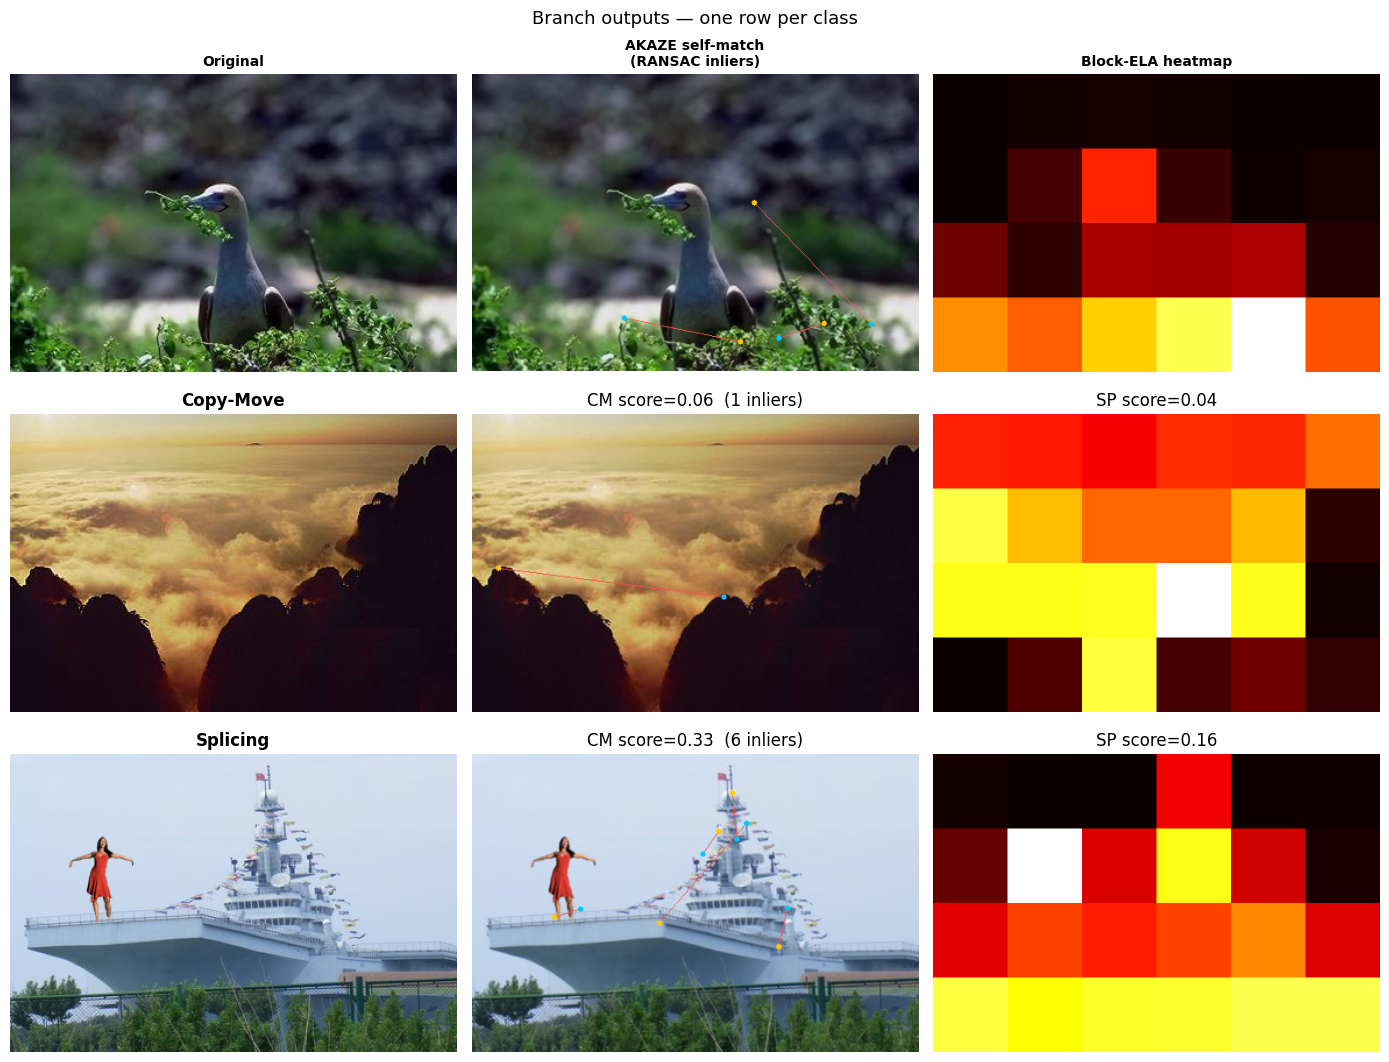

In [4]:
sample_paths = {
    "Authentic": random.choice(au_paths[:80]),
    "Copy-Move": random.choice(cm_paths[:80]),
    "Splicing":  random.choice(sp_paths[:80]),
}

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
col_titles = ["Original", "AKAZE self-match\n(RANSAC inliers)", "Block-ELA heatmap"]

for row, (label, p) in enumerate(sample_paths.items()):
    cm_score, n_inliers, matches = akaze_copymove_score(p)
    sp_score, _                  = ela_splicing_score(p)
    ela_raw, ela_blocks          = visualize_ela_blocks(p)

    axes[row, 0].imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"{label}", fontweight="bold")

    axes[row, 1].imshow(visualize_copymove(p, matches))
    axes[row, 1].set_title(f"CM score={cm_score:.2f}  ({n_inliers} inliers)")

    axes[row, 2].imshow(ela_blocks, cmap="hot")
    axes[row, 2].set_title(f"SP score={sp_score:.2f}")

    for ax in axes[row]:
        ax.axis("off")

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=10, fontweight="bold")

plt.suptitle("Branch outputs — one row per class", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
FEATURE_NAMES = [
    # AKAZE branch (3)
    "cm_score", "n_inliers", "inlier_density",
    # Block-ELA branch (6)
    "ela_mean", "ela_std", "block_std", "block_range", "lvar_max", "lvar_mean",
]

def extract_features(path):
    """9-dim feature vector from both branches."""
    cm_score, n_inliers, _ = akaze_copymove_score(path)

    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot read {path}")
    h, w = img.shape
    inlier_density = n_inliers / max(h * w / (512 * 512), 0.1)

    sp_score, ela_feats = ela_splicing_score(path)

    feat = np.array([
        cm_score, float(n_inliers), inlier_density,
        ela_feats.get("ela_mean",    0.0),
        ela_feats.get("ela_std",     0.0),
        ela_feats.get("block_std",   0.0),
        ela_feats.get("block_range", 0.0),
        ela_feats.get("lvar_max",    0.0),
        ela_feats.get("lvar_mean",   0.0),
    ], dtype=np.float32)

    return feat, cm_score, sp_score

In [6]:
N = 300   # samples per class; raise to 500+ for final evaluation

au_samp = random.sample(au_paths, min(N, len(au_paths)))
cm_samp = random.sample(cm_paths, min(N, len(cm_paths)))
sp_samp = random.sample(sp_paths, min(N, len(sp_paths)))

def extract_batch(paths, label):
    feats, labels, cm_scores, sp_scores = [], [], [], []
    for p in paths:
        try:
            f, cm_s, sp_s = extract_features(p)
            feats.append(f); labels.append(label)
            cm_scores.append(cm_s); sp_scores.append(sp_s)
        except Exception:
            pass
    return feats, labels, cm_scores, sp_scores

print("Extracting features — ~2–4 min for 900 images …")
f0, l0, cm0, sp0 = extract_batch(au_samp, 0)
f1, l1, cm1, sp1 = extract_batch(cm_samp, 1)
f2, l2, cm2, sp2 = extract_batch(sp_samp, 2)

X      = np.array(f0 + f1 + f2, dtype=np.float32)
y      = np.array(l0 + l1 + l2)
cm_all = np.array(cm0 + cm1 + cm2)
sp_all = np.array(sp0 + sp1 + sp2)

print(f"Feature matrix: {X.shape}  |  Classes: {collections.Counter(y)}")

Extracting features — ~2–4 min for 900 images …
Feature matrix: (900, 9)  |  Classes: Counter({np.int64(0): 300, np.int64(1): 300, np.int64(2): 300})


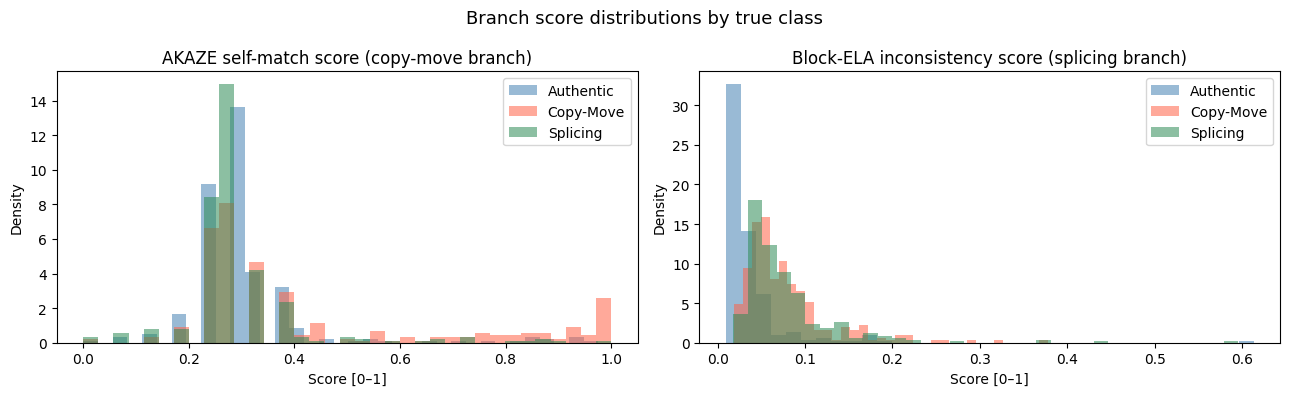

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cls in [0, 1, 2]:
    mask = y == cls
    axes[0].hist(cm_all[mask], bins=35, alpha=0.55,
                 color=COLORS[cls], label=NAMES[cls], density=True)
    axes[1].hist(sp_all[mask], bins=35, alpha=0.55,
                 color=COLORS[cls], label=NAMES[cls], density=True)

axes[0].set_title("AKAZE self-match score (copy-move branch)")
axes[1].set_title("Block-ELA inconsistency score (splicing branch)")
for ax in axes:
    ax.set_xlabel("Score [0–1]")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Branch score distributions by true class", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
idx = np.arange(len(y))
tr_idx, te_idx = train_test_split(idx, test_size=0.25, stratify=y, random_state=42)

cm_tr, sp_tr, y_tr = cm_all[tr_idx], sp_all[tr_idx], y[tr_idx]
cm_te, sp_te, y_te = cm_all[te_idx], sp_all[te_idx], y[te_idx]

scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X[tr_idx])
X_te_s   = scaler.transform(X[te_idx])

In [9]:
def threshold_predict(cm_score, sp_score, cm_t, sp_t):
    """Copy-move gets priority: if both fire, trust the higher-confidence branch."""
    if cm_score >= cm_t and cm_score >= sp_score:
        return 1
    elif sp_score >= sp_t:
        return 2
    return 0

best_bal, best_cm_t, best_sp_t = 0.0, 0.35, 0.20

for cm_t in np.arange(0.10, 0.70, 0.05):
    for sp_t in np.arange(0.10, 0.60, 0.05):
        preds = [threshold_predict(c, s, cm_t, sp_t) for c, s in zip(cm_tr, sp_tr)]
        bal   = balanced_accuracy_score(y_tr, preds)
        if bal > best_bal:
            best_bal, best_cm_t, best_sp_t = bal, cm_t, sp_t

print(f"Optimal thresholds  →  CM: {best_cm_t:.2f}   SP: {best_sp_t:.2f}")
print(f"Train balanced accuracy: {best_bal:.3f}")

preds_thresh = [threshold_predict(c, s, best_cm_t, best_sp_t)
                for c, s in zip(cm_te, sp_te)]
print("\n=== Threshold classifier (test set) ===")
print(classification_report(y_te, preds_thresh, target_names=list(NAMES.values())))
print(f"Balanced accuracy: {balanced_accuracy_score(y_te, preds_thresh):.3f}")

Optimal thresholds  →  CM: 0.30   SP: 0.10
Train balanced accuracy: 0.462

=== Threshold classifier (test set) ===
              precision    recall  f1-score   support

   Authentic       0.41      0.68      0.52        75
   Copy-Move       0.46      0.51      0.48        75
    Splicing       0.58      0.15      0.23        75

    accuracy                           0.44       225
   macro avg       0.48      0.44      0.41       225
weighted avg       0.48      0.44      0.41       225

Balanced accuracy: 0.444


In [11]:
# Option A: 2-feature input
lr_2d = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", solver="lbfgs")
lr_2d.fit(np.column_stack([cm_tr, sp_tr]), y_tr)
preds_lr2 = lr_2d.predict(np.column_stack([cm_te, sp_te]))

# Option B: full 9-feature input
lr_9d = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", solver="lbfgs")
lr_9d.fit(X_tr_s, y_tr)
preds_lr9 = lr_9d.predict(X_te_s)

# Option C: Random Forest on 9 features (best accuracy)
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X_tr_s, y_tr)
preds_rf = rf.predict(X_te_s)

for name, preds in [("LR (2 scores)", preds_lr2),
                    ("LR (9 features)", preds_lr9),
                    ("RF (9 features)", preds_rf)]:
    bal = balanced_accuracy_score(y_te, preds)
    print(f"\n=== {name}  —  balanced acc: {bal:.3f} ===")
    print(classification_report(y_te, preds, target_names=list(NAMES.values())))


=== LR (2 scores)  —  balanced acc: 0.560 ===
              precision    recall  f1-score   support

   Authentic       0.54      0.84      0.66        75
   Copy-Move       0.62      0.33      0.43        75
    Splicing       0.55      0.51      0.53        75

    accuracy                           0.56       225
   macro avg       0.57      0.56      0.54       225
weighted avg       0.57      0.56      0.54       225


=== LR (9 features)  —  balanced acc: 0.609 ===
              precision    recall  f1-score   support

   Authentic       0.65      0.79      0.71        75
   Copy-Move       0.64      0.45      0.53        75
    Splicing       0.54      0.59      0.56        75

    accuracy                           0.61       225
   macro avg       0.61      0.61      0.60       225
weighted avg       0.61      0.61      0.60       225


=== RF (9 features)  —  balanced acc: 0.671 ===
              precision    recall  f1-score   support

   Authentic       0.80      0.80     

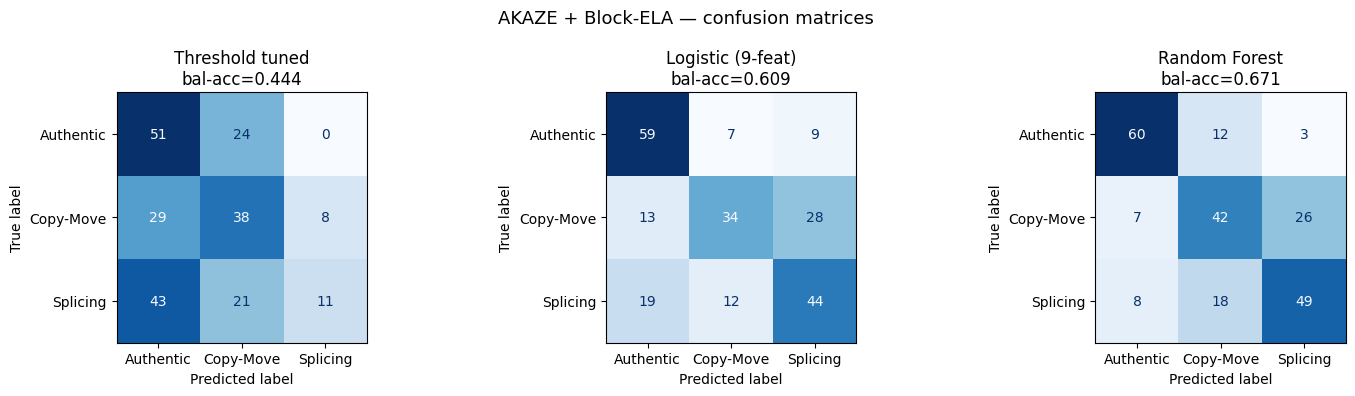

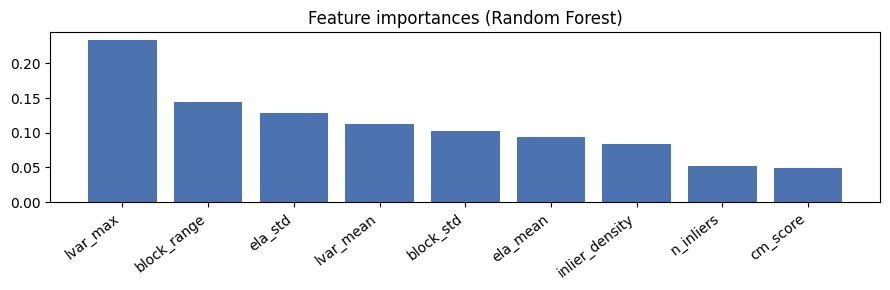

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    ("Threshold tuned",  preds_thresh),
    ("Logistic (9-feat)", preds_lr9),
    ("Random Forest",    preds_rf),
]
for ax, (title, preds) in zip(axes, pairs):
    cm_mat = confusion_matrix(y_te, preds)
    ConfusionMatrixDisplay(cm_mat, display_labels=list(NAMES.values())).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{title}\nbal-acc={balanced_accuracy_score(y_te, preds):.3f}")

plt.suptitle("AKAZE + Block-ELA — confusion matrices", fontsize=13)
plt.tight_layout()
plt.show()

# Feature importances from RF
imps  = rf.feature_importances_
order = np.argsort(imps)[::-1]
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(9), imps[order], color="#4C72B0")
ax.set_xticks(range(9))
ax.set_xticklabels([FEATURE_NAMES[i] for i in order], rotation=38, ha="right")
ax.set_title("Feature importances (Random Forest)")
plt.tight_layout()
plt.show()


──────────────────────────────────────────────────
True class: Authentic  |  File: Au_ani_00054.jpg


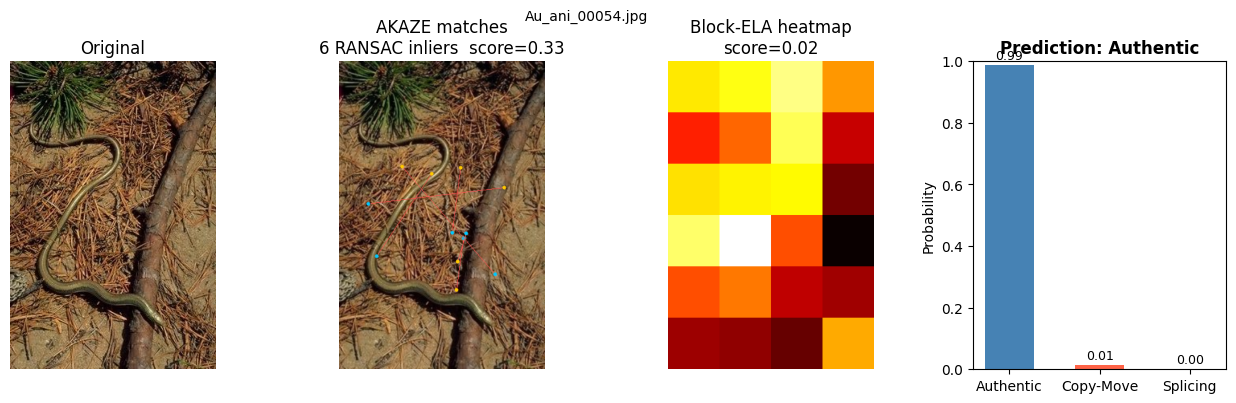

Predicted : Authentic  (confidence: 0.99)

──────────────────────────────────────────────────
True class: Copy-Move  |  File: Tp_D_NRD_L_B_arc20049_arc20049_02480.tif


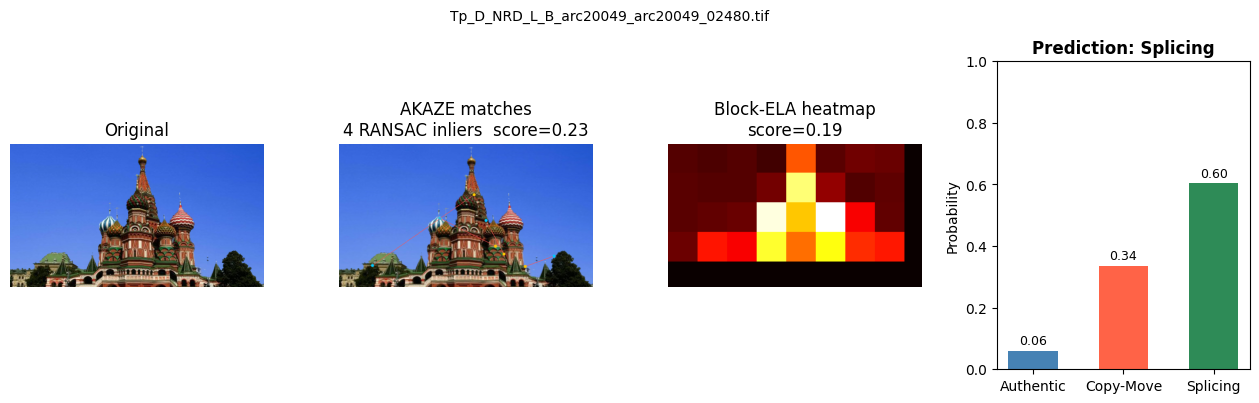

Predicted : Splicing  (confidence: 0.60)

──────────────────────────────────────────────────
True class: Splicing  |  File: Tp_D_CNN_M_N_nat00041_nat10123_11439.jpg


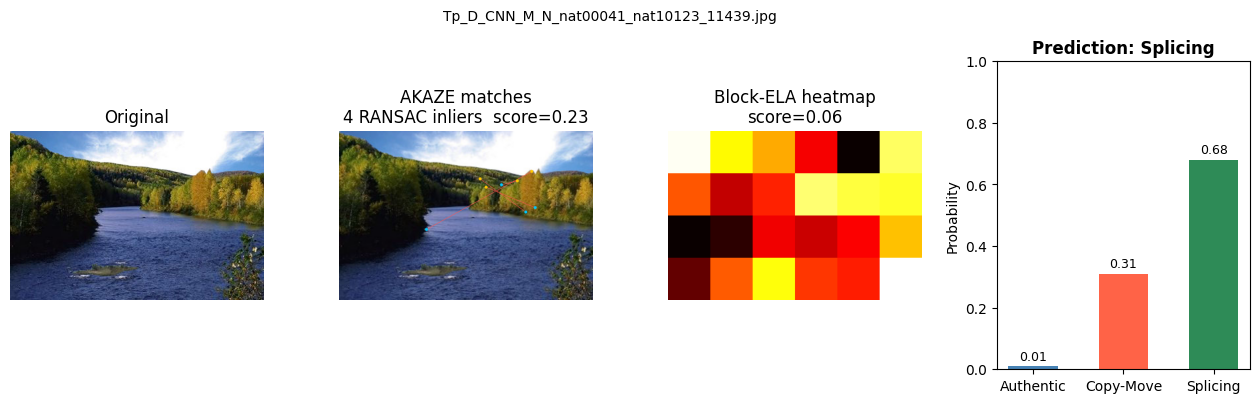

Predicted : Splicing  (confidence: 0.68)


In [13]:
def predict_image(path, classifier=rf, scaler=scaler):
    """
    Run the full pipeline on one image and display all diagnostic outputs.
    Uses the RF model by default; pass lr_2d for a lightweight deployment version.
    """
    cm_score, n_inliers, matches = akaze_copymove_score(path)
    sp_score, ela_feats          = ela_splicing_score(path)
    ela_raw, ela_blocks          = visualize_ela_blocks(path)

    feat         = np.array([
        cm_score, float(n_inliers),
        n_inliers / max(cv2.imread(str(path), cv2.IMREAD_GRAYSCALE).size / (512*512), 0.1),
        ela_feats.get("ela_mean", 0), ela_feats.get("ela_std", 0),
        ela_feats.get("block_std", 0), ela_feats.get("block_range", 0),
        ela_feats.get("lvar_max", 0), ela_feats.get("lvar_mean", 0),
    ], dtype=np.float32)
    feat_s       = scaler.transform(feat.reshape(1, -1))
    pred_cls     = classifier.predict(feat_s)[0]
    probas       = classifier.predict_proba(feat_s)[0]
    pred_label   = NAMES[pred_cls]

    # ── Build figure ─────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 4))
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.3)

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB))
    ax0.set_title("Original"); ax0.axis("off")

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(visualize_copymove(path, matches))
    ax1.set_title(f"AKAZE matches\n{n_inliers} RANSAC inliers  score={cm_score:.2f}")
    ax1.axis("off")

    ax2 = fig.add_subplot(gs[2])
    ax2.imshow(ela_blocks, cmap="hot")
    ax2.set_title(f"Block-ELA heatmap\nscore={sp_score:.2f}")
    ax2.axis("off")

    ax3 = fig.add_subplot(gs[3])
    bar_colors = [COLORS[i] for i in range(3)]
    bars = ax3.bar(list(NAMES.values()), probas, color=bar_colors, width=0.55)
    ax3.set_ylim(0, 1); ax3.set_ylabel("Probability")
    ax3.set_title(f"Prediction: {pred_label}", fontweight="bold")
    for bar, p in zip(bars, probas):
        ax3.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02, f"{p:.2f}", ha="center", fontsize=9)

    plt.suptitle(path.name, fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()
    return pred_label, probas


# Run on one example of each class
for label, paths in [("Authentic", au_paths), ("Copy-Move", cm_paths), ("Splicing", sp_paths)]:
    p = random.choice(paths[:60])
    print(f"\n{'─'*50}\nTrue class: {label}  |  File: {p.name}")
    pred, prob = predict_image(p)
    print(f"Predicted : {pred}  (confidence: {prob.max():.2f})")